#  Análise Exploratória de Dados - Análise Univariada: The Movies Dataset

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))

# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb
import src.utils.reshaping as rsh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [3]:
caminho = '../data/interim/movies/movies_enriched.parquet'
df_movies = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (41091, 22)


---

## Colunas do DataFrame

In [4]:
df_colunas = pd.DataFrame({
    "coluna": df_movies.columns,
    "dtype_pandas": df_movies.dtypes.values,
    "tipo_real": [
        df_movies[col].map(type)[0].__name__
        if not df_movies[col].dropna().empty else None
        for col in df_movies.columns
    ]
})

display(tb.estilizar_tabela(
    df=df_colunas,
    caption="Colunas do dataframe"
))

,coluna,dtype_pandas,tipo_real
0,belongs_to_collection,object,str
1,budget,float64,float
2,genres,object,ndarray
3,id,int64,int
4,original_language,object,str
5,original_title,object,str
6,popularity,float64,float
7,producer_company,object,ndarray
8,production_countries,object,ndarray
9,release_date,datetime64[ns],Timestamp


### Colunas Numéricas

In [5]:
# Análisado Colunas Numéricas Individualmente
resumo_cols_numericas = mt.numeric_summary(df_movies)
display(
    tb.estilizar_tabela(
        resumo_cols_numericas,
        caption="Relatorio colunas numéricas"
    ).format("{:,.2f}")
)

,mean,median,std,min,max,iqr,skew,kurtosis,outlier_count,outlier_%
column,,,,,,,,,,
revenue,"69,309,229.77","17,062,499.00","146,886,994.59",1.00,"2,787,965,087.00","65,635,038.00",5.13,42.70,831.00,11.31
budget,"21,956,783.82","8,820,000.00","34,512,754.61",1.00,"380,000,000.00","23,697,387.00",3.10,12.57,812.00,9.30
id,"99,432.89","52,907.00","108,089.16",2.00,"468,707.00","108,569.00",1.45,1.07,"3,736.00",9.09
release_year,"1,991.97","2,001.00",23.99,"1,874.00","2,018.00",31.00,-1.23,0.88,977.00,2.38
decade,"1,987.52","2,000.00",24.19,"1,870.00","2,010.00",40.00,-1.20,0.83,158.00,0.38
total_votes,121.27,12.00,515.45,1.00,"14,075.00",36.00,9.95,136.94,"6,215.00",15.12
runtime,98.11,96.00,34.42,1.00,"1,256.00",21.00,7.00,152.15,"3,855.00",9.38
global_score,60.10,61.00,12.69,0.00,100.00,15.00,-0.67,1.84,"1,196.00",2.91
age_years,34.03,25.00,23.99,8.00,152.00,31.00,1.23,0.88,977.00,2.38


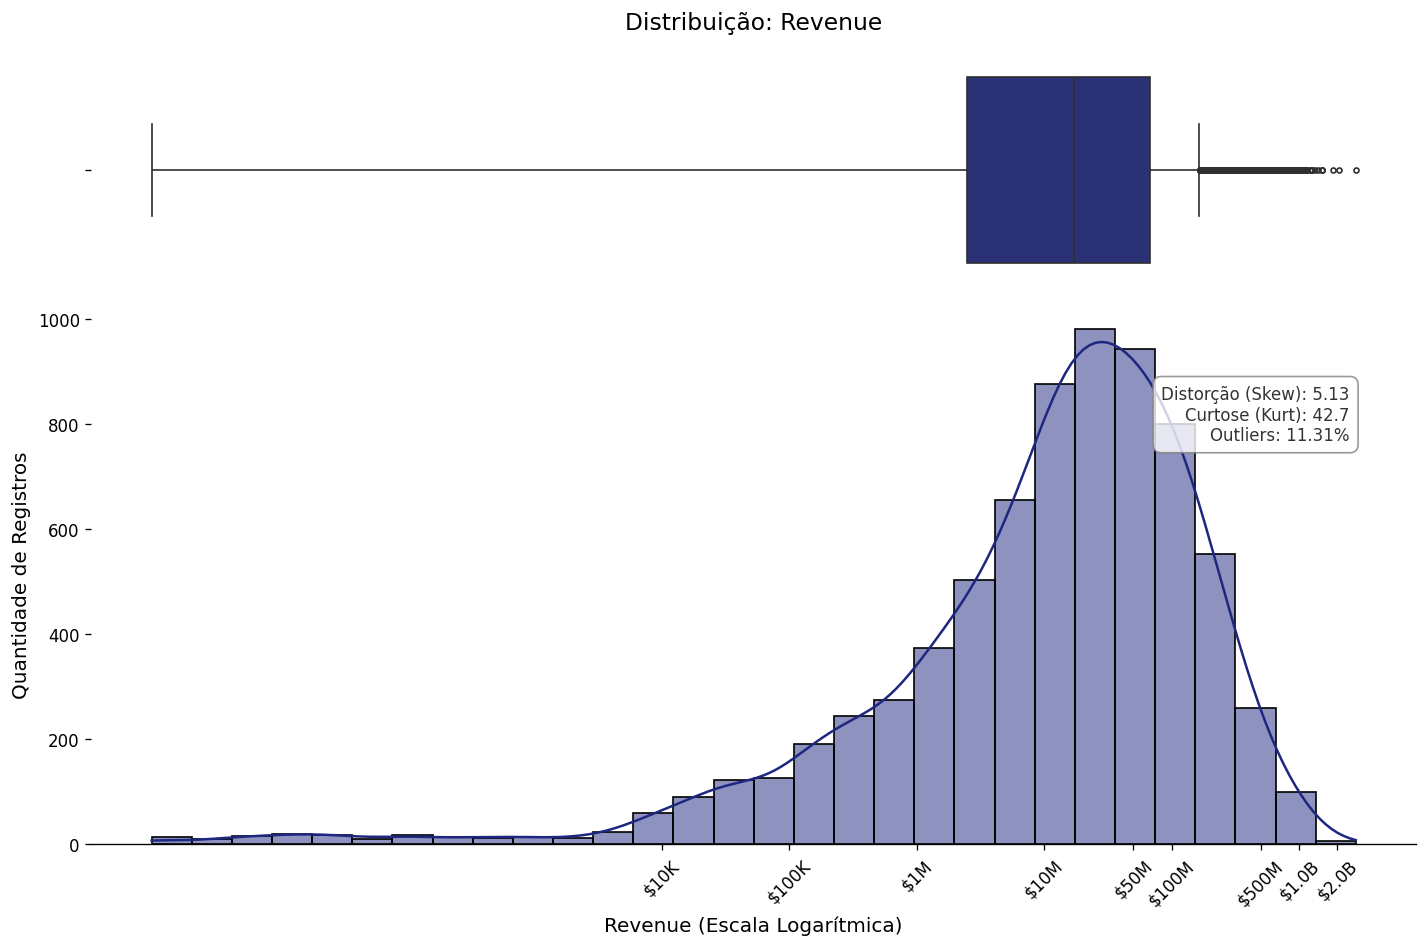

In [6]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='revenue', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='moeda'
)

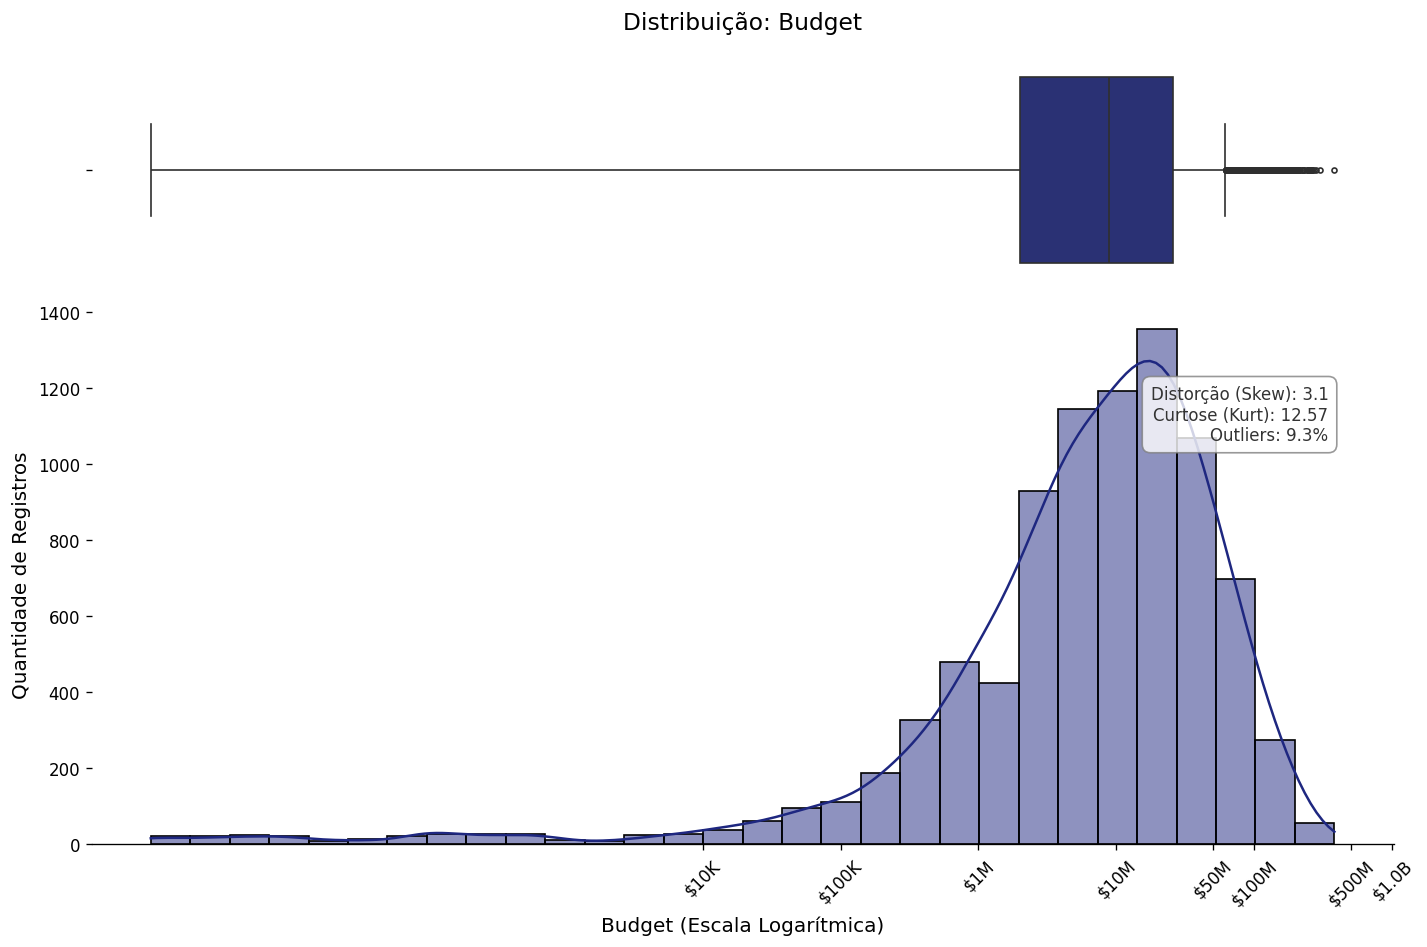

In [7]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='budget', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='moeda'
)

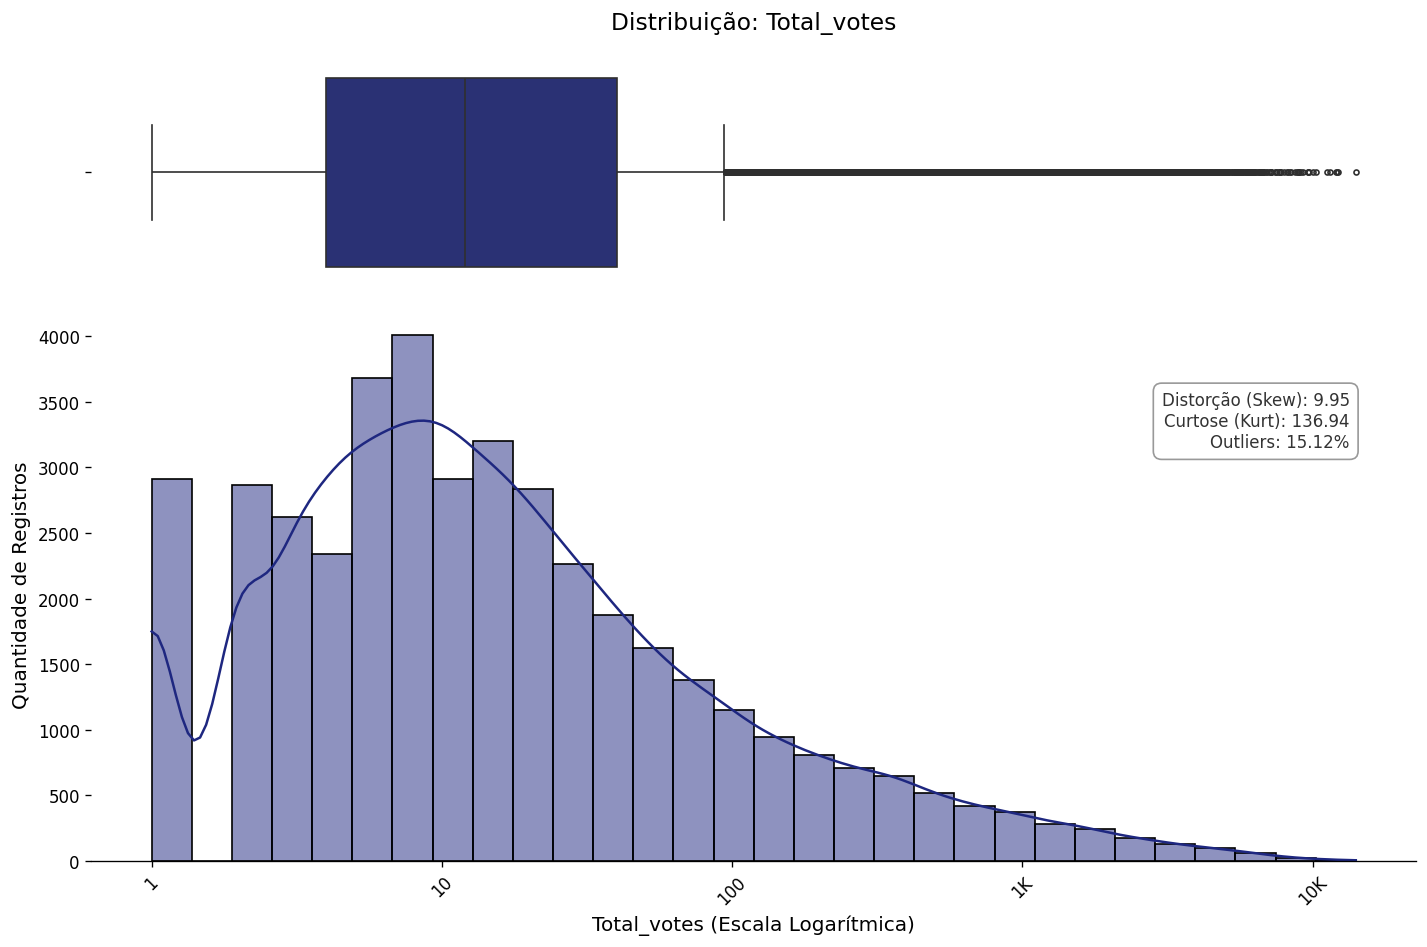

In [8]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='total_votes', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

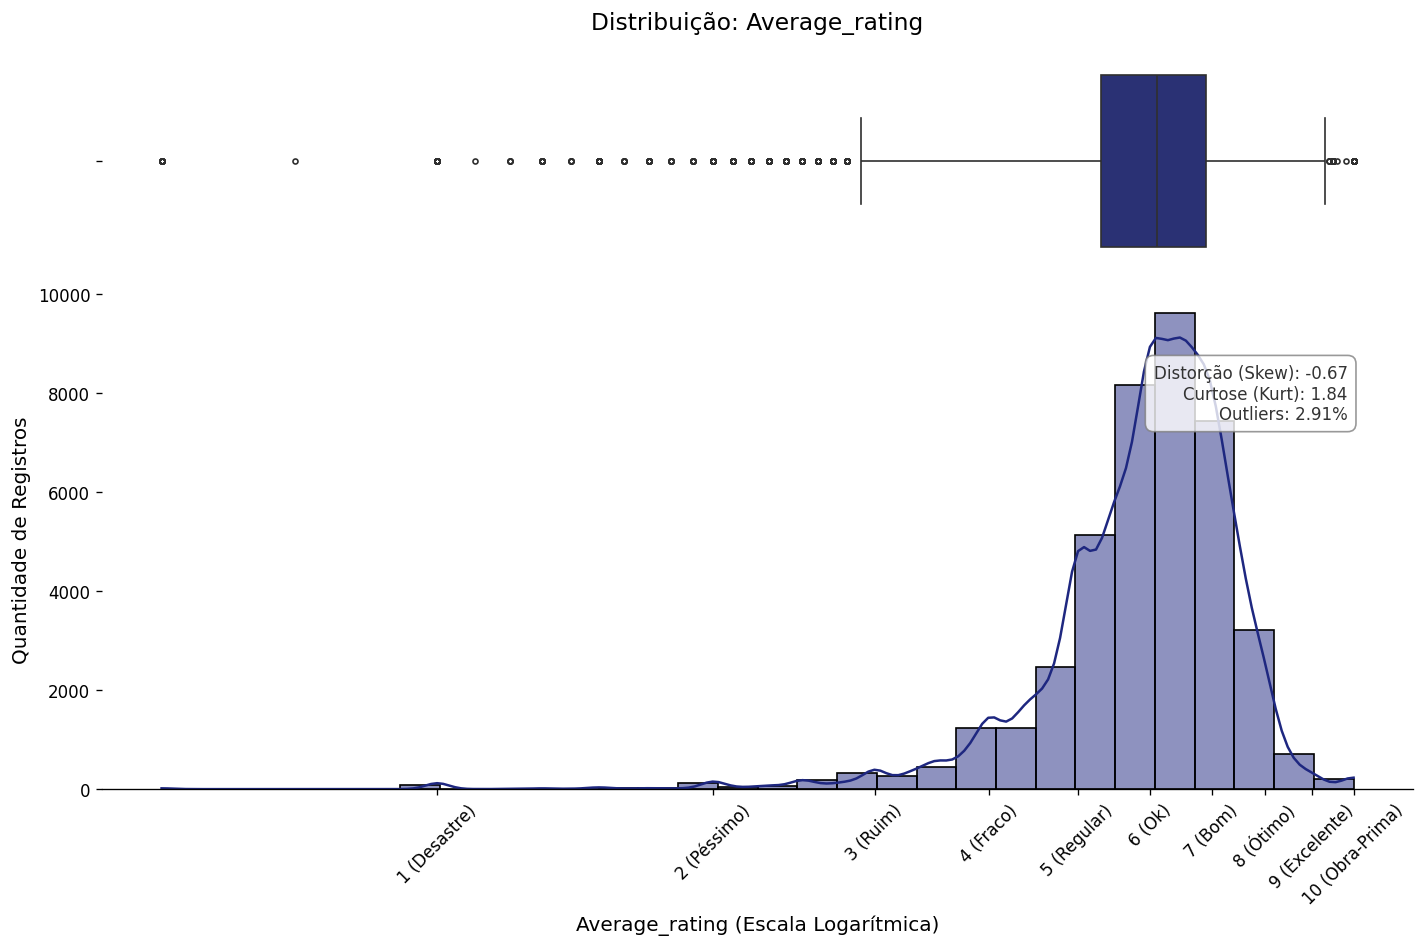

In [9]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='average_rating', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='nota_10'
)

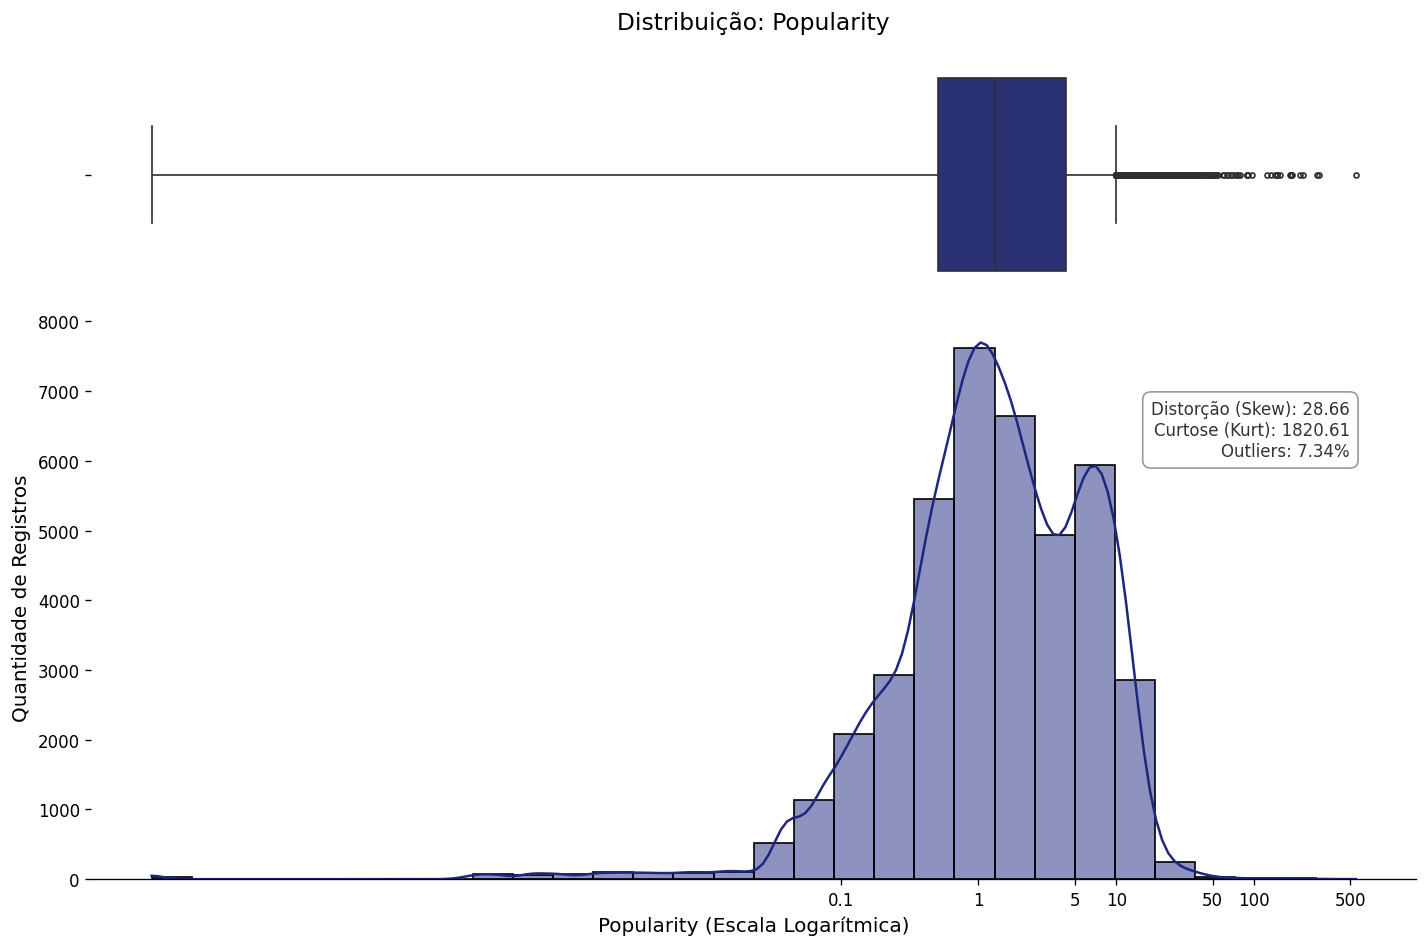

In [10]:
graf.grafico_distribuicao_numerica(
    df_movies, 
    coluna='popularity', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True,
    tipo_dado='popularidade'
)

### Colunas Ctategoricas

In [11]:
# Análisado Colunas Categorical Individualmente
resumo_cols_categoricas = mt.categorical_summary(df_movies)
display(
    tb.estilizar_relatorio_categorias(
        resumo_cols_categoricas,
        caption="Relatorio colunas categoricas"
    )
)

,total_valid_rows,unique_categories,entropy_norm,top_values_count,top_values_pct_%
column,,,,,
original_title,41091,39206,0.997900,• Alice in Wonderland (8)• Hamlet (7)• Les Misérables (7)• The Three Musketeers (7)• Cinderella (7)• A Christmas Carol (7)• Macbeth (7)• Wuthering Heights (6)• Heidi (6)• King Lear (6),• Alice in Wonderland (0.0%)• Hamlet (0.0%)• Les Misérables (0.0%)• The Three Musketeers (0.0%)• Cinderella (0.0%)• A Christmas Carol (0.0%)• Macbeth (0.0%)• Wuthering Heights (0.0%)• Heidi (0.0%)• King Lear (0.0%)
title,41091,38233,0.996600,• Cinderella (11)• Alice in Wonderland (9)• Hamlet (8)• Les Misérables (7)• Beauty and the Beast (7)• The Three Musketeers (7)• Treasure Island (7)• A Christmas Carol (7)• Blackout (7)• The Hunters (6),• Cinderella (0.0%)• Alice in Wonderland (0.0%)• Hamlet (0.0%)• Les Misérables (0.0%)• Beauty and the Beast (0.0%)• The Three Musketeers (0.0%)• Treasure Island (0.0%)• A Christmas Carol (0.0%)• Blackout (0.0%)• The Hunters (0.0%)
popularity_tier,41091,4,0.990700,• Mainstream Hit (12233)• Nicho (11545)• Hidden Gem / Cult (8951)• Mass Appeal (8362),• Mainstream Hit (29.8%)• Nicho (28.1%)• Hidden Gem / Cult (21.8%)• Mass Appeal (20.3%)
genres,41091,21,0.871500,• Drama (19020)• Comedy (12165)• Thriller (7324)• Romance (6367)• Action (6302)• Horror (4526)• Crime (4086)• Adventure (3337)• Documentary (3326)• Science Fiction (2931),• Drama (46.3%)• Comedy (29.6%)• Thriller (17.8%)• Romance (15.5%)• Action (15.3%)• Horror (11.0%)• Crime (9.9%)• Adventure (8.1%)• Documentary (8.1%)• Science Fiction (7.1%)
producer_company,41091,22648,0.810000,• Companhia Não Identificada (9318)• Warner Bros. (1183)• Metro-Goldwyn-Mayer (MGM) (993)• Paramount Pictures (972)• Universal Pictures (818)• Twentieth Century Fox Film Corporation (812)• Canal+ (433)• Columbia Pictures Corporation (427)• Columbia Pictures (420)• New Line Cinema (277),• Companhia Não Identificada (22.7%)• Warner Bros. (2.9%)• Metro-Goldwyn-Mayer (MGM) (2.4%)• Paramount Pictures (2.4%)• Universal Pictures (2.0%)• Twentieth Century Fox Film Corporation (2.0%)• Canal+ (1.1%)• Columbia Pictures Corporation (1.0%)• Columbia Pictures (1.0%)• New Line Cinema (0.7%)
production_countries,41091,159,0.517800,• United States of America (20064)• País Não Identificado (4511)• United Kingdom (3949)• France (3736)• Germany (2096)• Italy (1848)• Canada (1663)• Japan (1560)• Russia (859)• Spain (853),• United States of America (48.8%)• País Não Identificado (11.0%)• United Kingdom (9.6%)• France (9.1%)• Germany (5.1%)• Italy (4.5%)• Canada (4.0%)• Japan (3.8%)• Russia (2.1%)• Spain (2.1%)
spoken_languages,41091,76,0.503600,• English (27163)• Français (3945)• Deutsch (2447)• Idioma Não Identificado (2432)• Español (2249)• Italiano (2043)• 日本語 (1665)• Pусский (1478)• 普通话 (765)• हिन्दी (635),• English (66.1%)• Français (9.6%)• Deutsch (6.0%)• Idioma Não Identificado (5.9%)• Español (5.5%)• Italiano (5.0%)• 日本語 (4.1%)• Pусский (3.6%)• 普通话 (1.9%)• हिन्दी (1.5%)
original_language,41091,85,0.322200,• en (29495)• fr (2226)• ja (1280)• it (1134)• de (927)• es (848)• ru (752)• hi (463)• ko (441)• zh (397),• en (71.8%)• fr (5.4%)• ja (3.1%)• it (2.8%)• de (2.3%)• es (2.1%)• ru (1.8%)• hi (1.1%)• ko (1.1%)• zh (1.0%)
belongs_to_collection,41091,1659,0.148100,• Sem Coleção (36751)• James Bond Collection (26)• Zatôichi: The Blind Swordsman (26)• The Carry On Collection (25)• Pokémon Collection (22)• Charlie Chan (Sidney Toler) Collection (21)• Totò Collection (19)• Godzilla (Showa) Collection (16)• The Bowery Boys (15)• Dragon Ball Z (Movie) Collection (15),• Sem Coleção (89.4%)• James Bond Collection (0.1%)• Zatôichi: The Blind Swordsman (0.1%)• The Carry On Collection (0.1%)• Pokémon Collection (0.1%)• Charlie Chan (Sidney Toler) Collection (0.1%)• Totò Collection (0.0%)• Godzilla (Showa) Collection (0.0%)• The Bowery Boys (0.0%)• Dragon Ball Z (Movie) Collection (0.0%)


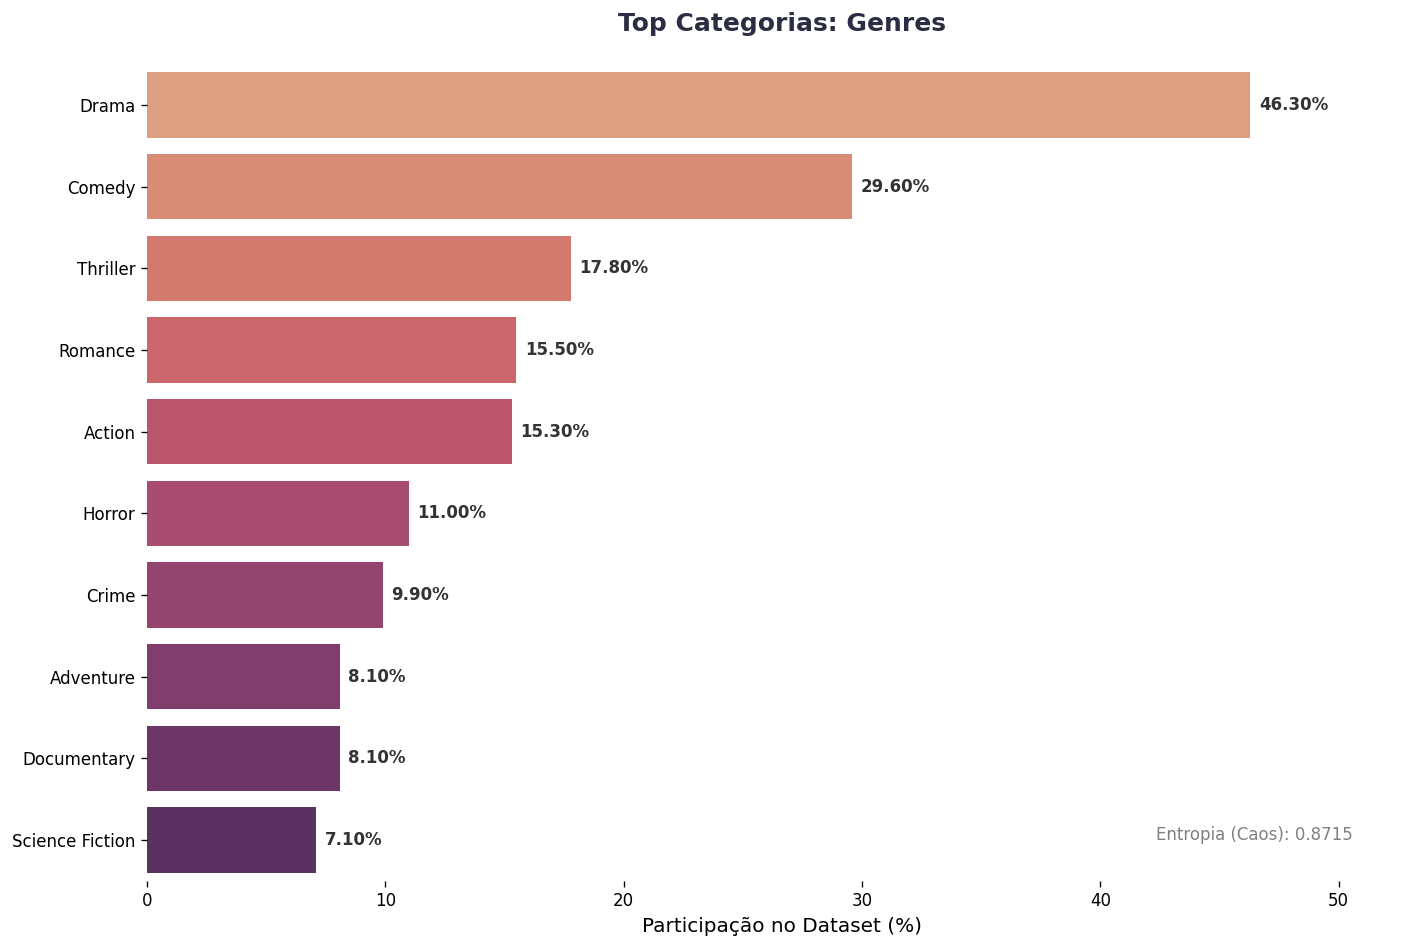

In [12]:
graf.grafico_top_categorias(df_movies, 'genres', resumo_cols_categoricas)

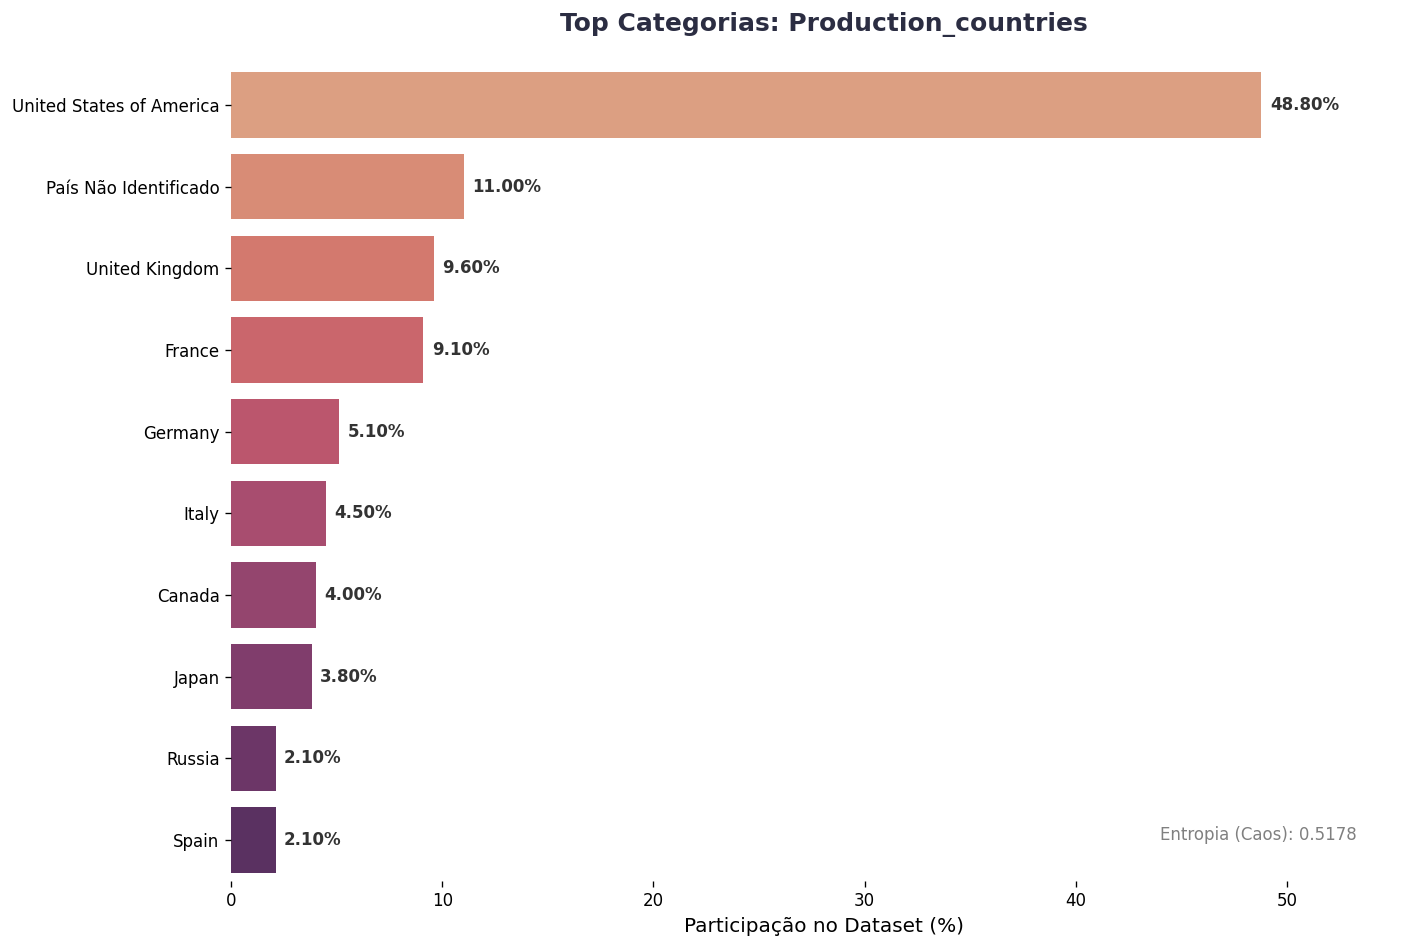

In [13]:
graf.grafico_top_categorias(df_movies, 'production_countries', resumo_cols_categoricas)

c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 26222 (\N{CJK UNIFIED IDEOGRAPH-666E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry_performance_analysis\src\view\plots.py:468: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Portfolio\entertainment_industry

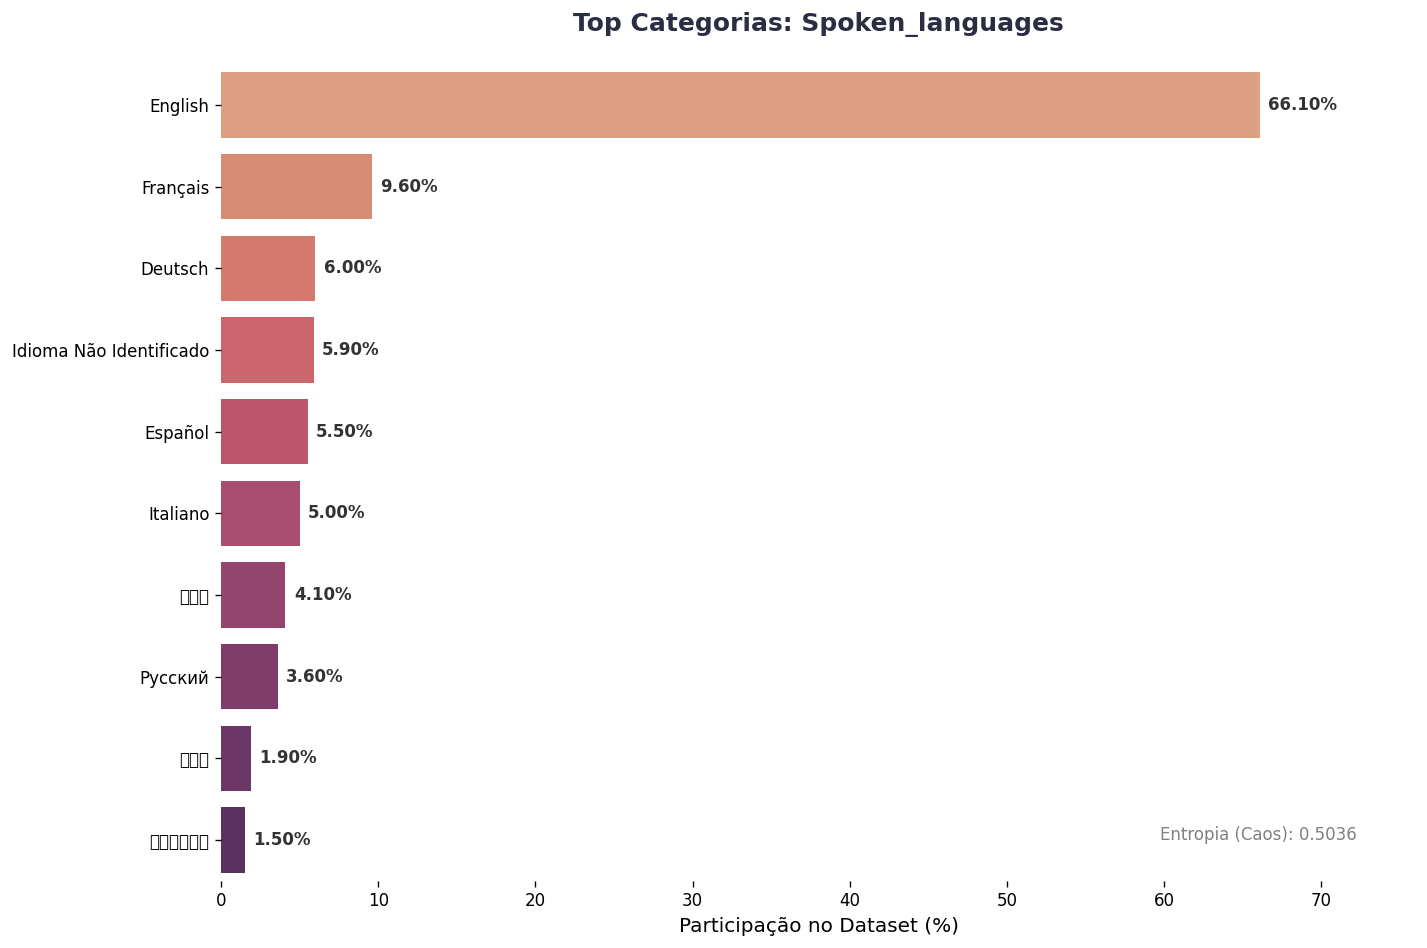

In [14]:
graf.grafico_top_categorias(df_movies, 'spoken_languages', resumo_cols_categoricas)

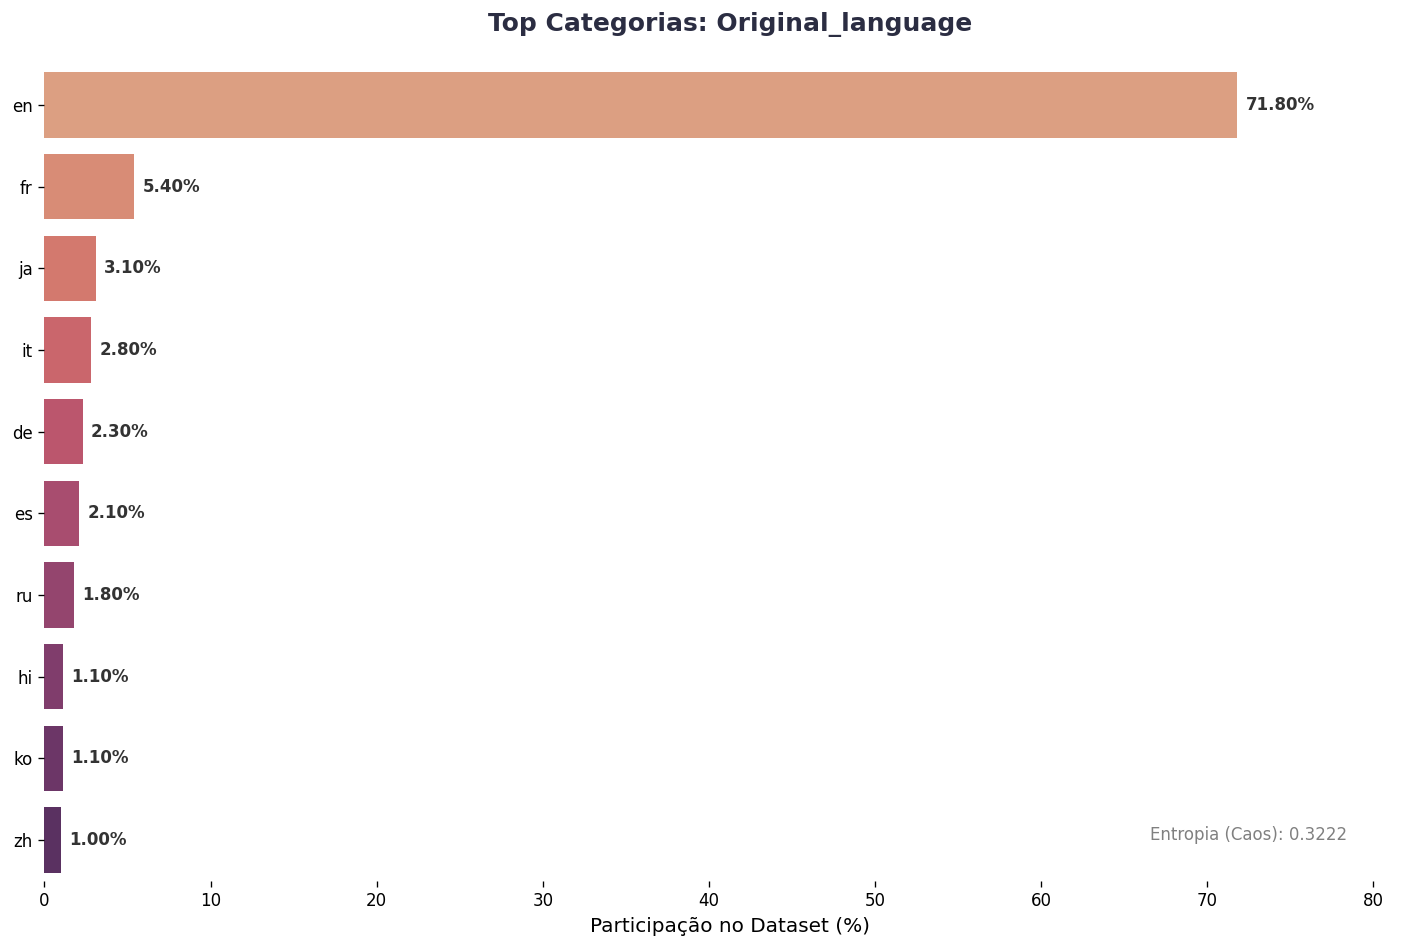

In [15]:
graf.grafico_top_categorias(df_movies, 'original_language', resumo_cols_categoricas)

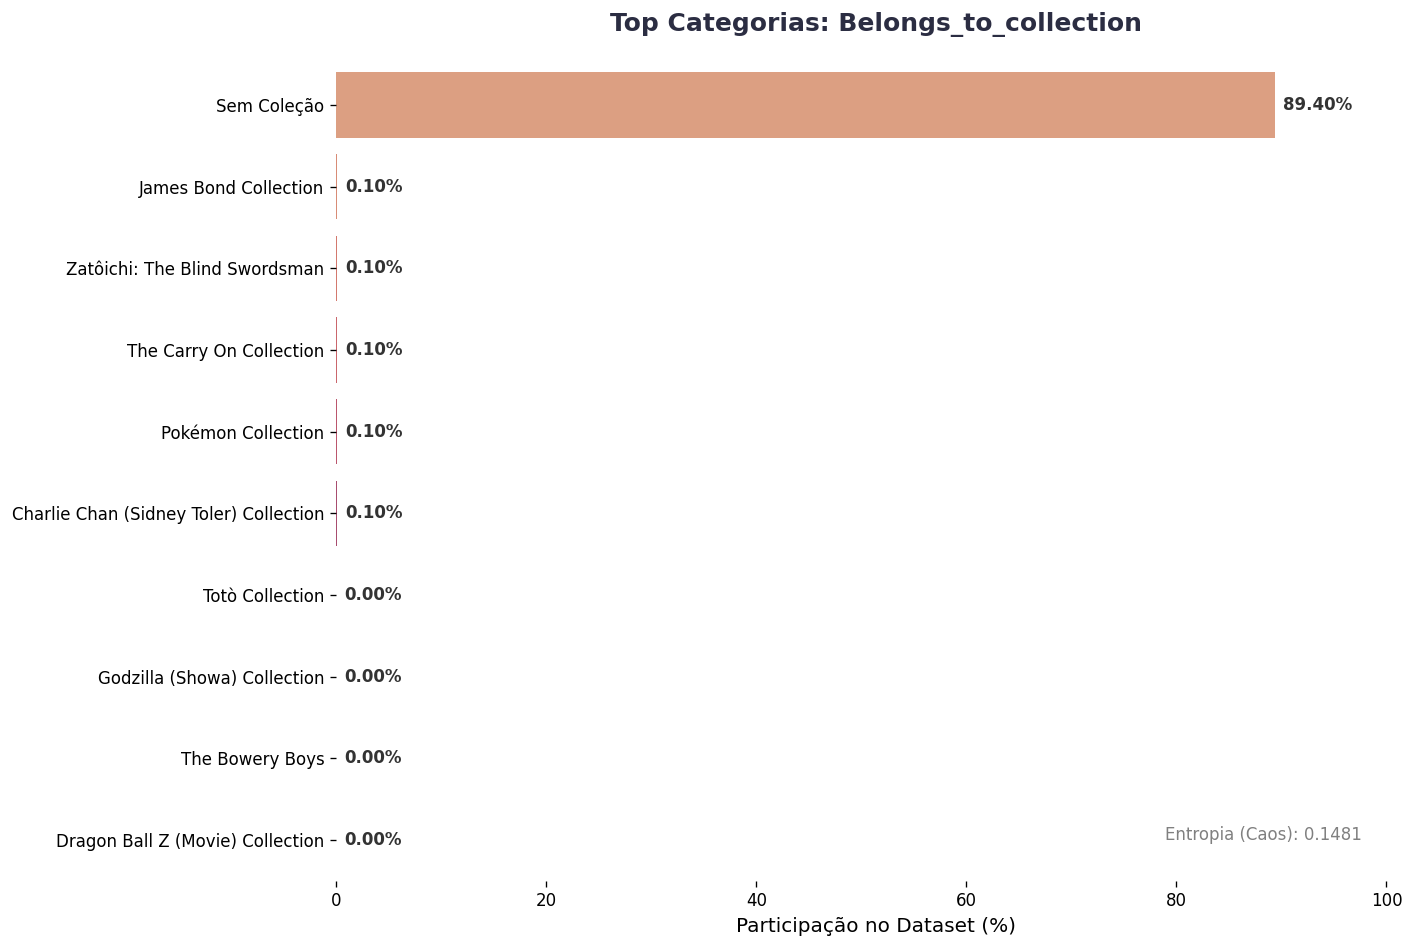

In [16]:
graf.grafico_top_categorias(df_movies, 'belongs_to_collection', resumo_cols_categoricas)

### Colunas de Tempo

In [17]:
relatorio_cols_date = mt.datetime_summary(df_movies)

display(
    tb.estilizar_tabela(
        relatorio_cols_date,
        caption="Relatorio colunas date"
    )
)

,min,max,range_years,unique_dates,most_frequent_year,most_frequent_month
column,,,,,,
release_date,1874-12-09,2018-04-04,143,16394,2014,1


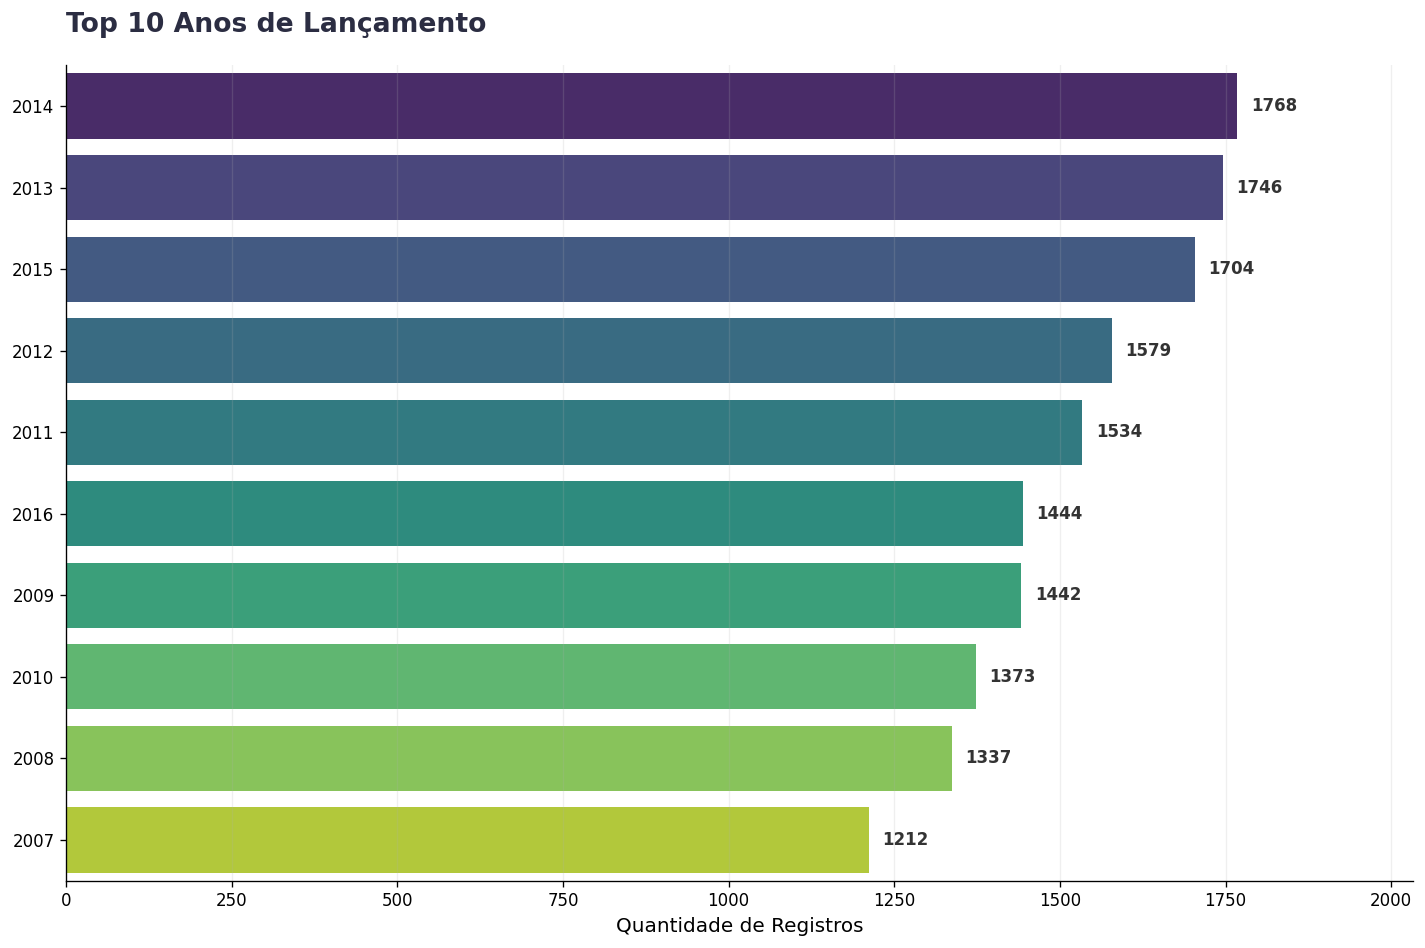

In [18]:
graf.graficos_top_release(df_movies, 'release_date', data='year')

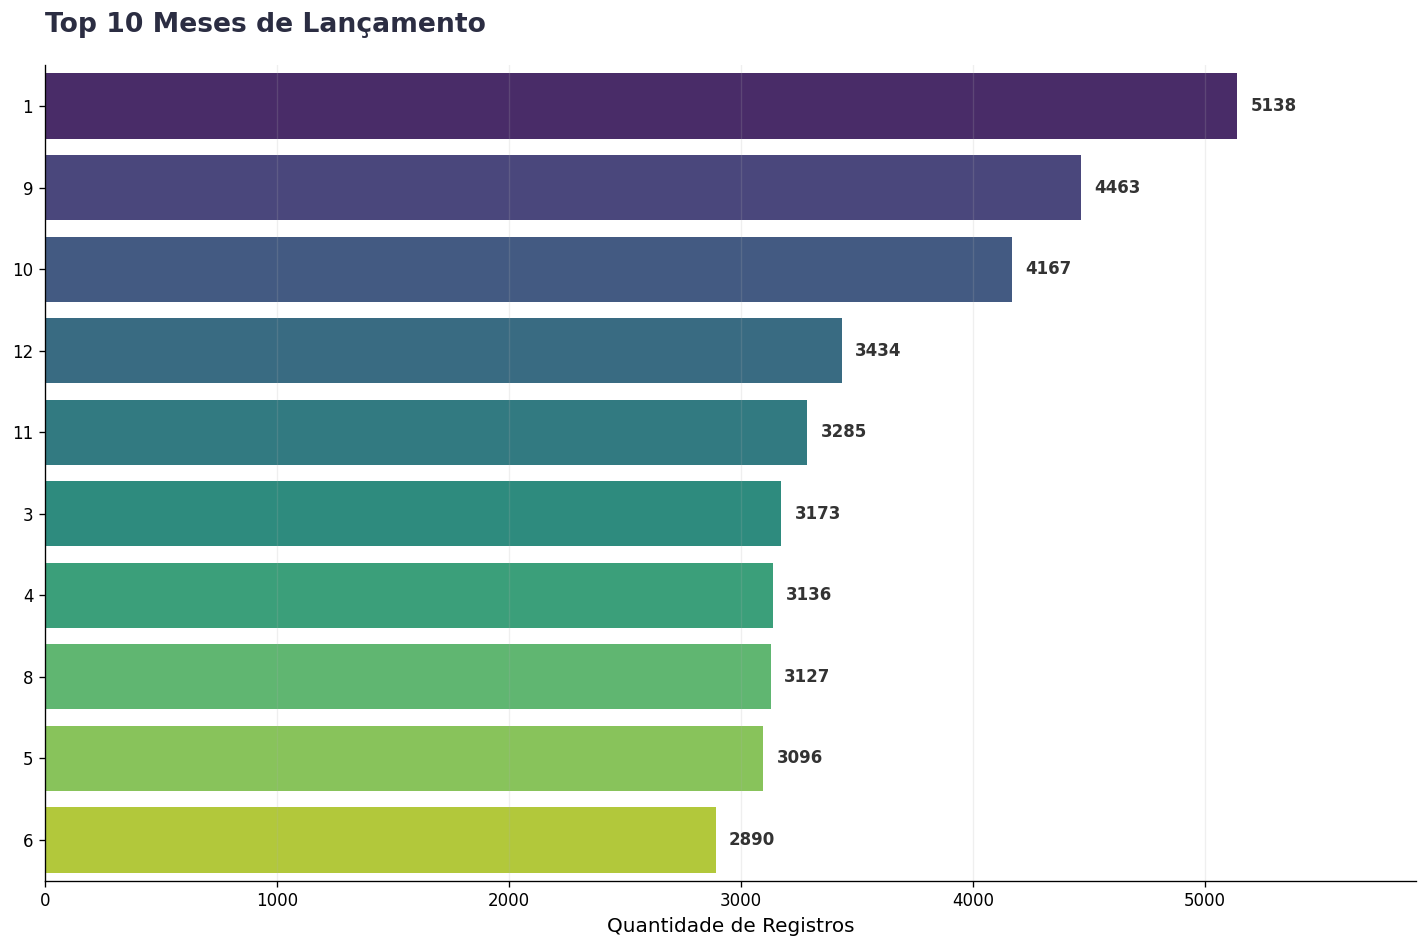

In [19]:
graf.graficos_top_release(df_movies, 'release_date', data='month')

## Conclusões da Análise Univariada 

### 1. Diagnóstico Estatístico (Métricas Numéricas)
* **Finanças e Engajamento (`revenue`, `budget`, `vote_count`):** Distribuição de **cauda longa** com assimetria extrema. O mercado é polarizado: a esmagadora maioria dos filmes tem baixo orçamento, pouca bilheteria e poucas avaliações, enquanto uma elite de blockbusters concentra o dinheiro e a atenção do público.
* **Avaliações (`vote_average`):** Segue uma **Distribuição Normal** perfeita, concentrada entre **6.0 e 7.5**. Notas extremas (0 ou 10) são raridades; a maior parte do catálogo habita a zona do entretenimento aceitável.

### 2. Padrões Categoriais
* **Concentração Geográfica e Linguística:** Baixa entropia, evidenciando a dominância absoluta de Hollywood (EUA) e do idioma inglês.
* **Diversidade de Gêneros:** Alta entropia. *Drama* e *Comédia* lideram em volume, mas o ecossistema de gêneros é bem distribuído.
* **Franquias:** Obras isoladas são a regra; coleções são exceções estruturais.

### 3. Comportamento Temporal
* **Evolução:** Abrange **143 anos** de cinema (1874 a 2018) com altíssima granularidade (**16.394 datas únicas**), tendo seu **pico histórico em 2014**.
* **Sazonalidade:** O **mês 1 (Janeiro)** lidera os registros, o que indica uma provável padronização de cadastro para filmes antigos, além de festivais e relançamentos.

### 4. Auditoria de Data Quality
* **Sujeira nos Dados:** Identificação de orçamentos e faturamentos irreais (ex: \$10), caracterizados como erros de preenchimento do TMDB e não como produções independentes legítimas.
* **Mitigação:** Aplicação de um filtro temporário (`>= 1_000_000`) para proteger os gráficos atuais, com substituição definitiva desses valores truncados por `NaN` na etapa de *Data Cleaning*.